In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler


In [4]:
df = pd.read_csv("housing.csv")

In [5]:
df.head(6)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].mean()
)

In [8]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [9]:
#Rooms per household
df["rooms_per_household"] = (
    df["total_rooms"] / df["households"]
)
print(df["rooms_per_household"])

0        6.984127
1        6.238137
2        8.288136
3        5.817352
4        6.281853
           ...   
20635    5.045455
20636    6.114035
20637    5.205543
20638    5.329513
20639    5.254717
Name: rooms_per_household, Length: 20640, dtype: float64


In [10]:
#Bedrooms per room
df["bedrooms_per_room"] = (
    df["total_bedrooms"] / df["total_rooms"]
)
print(df["bedrooms_per_room"])

0        0.146591
1        0.155797
2        0.129516
3        0.184458
4        0.172096
           ...   
20635    0.224625
20636    0.215208
20637    0.215173
20638    0.219892
20639    0.221185
Name: bedrooms_per_room, Length: 20640, dtype: float64


Shape: (20640, 12)

Missing values:
longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms         0
population             0
households             0
median_income          0
median_house_value     0
ocean_proximity        0
rooms_per_household    0
bedrooms_per_room      0
dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20640.0,537.870553,419.266592,1.0000,297.0000,438.0000,643.25000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


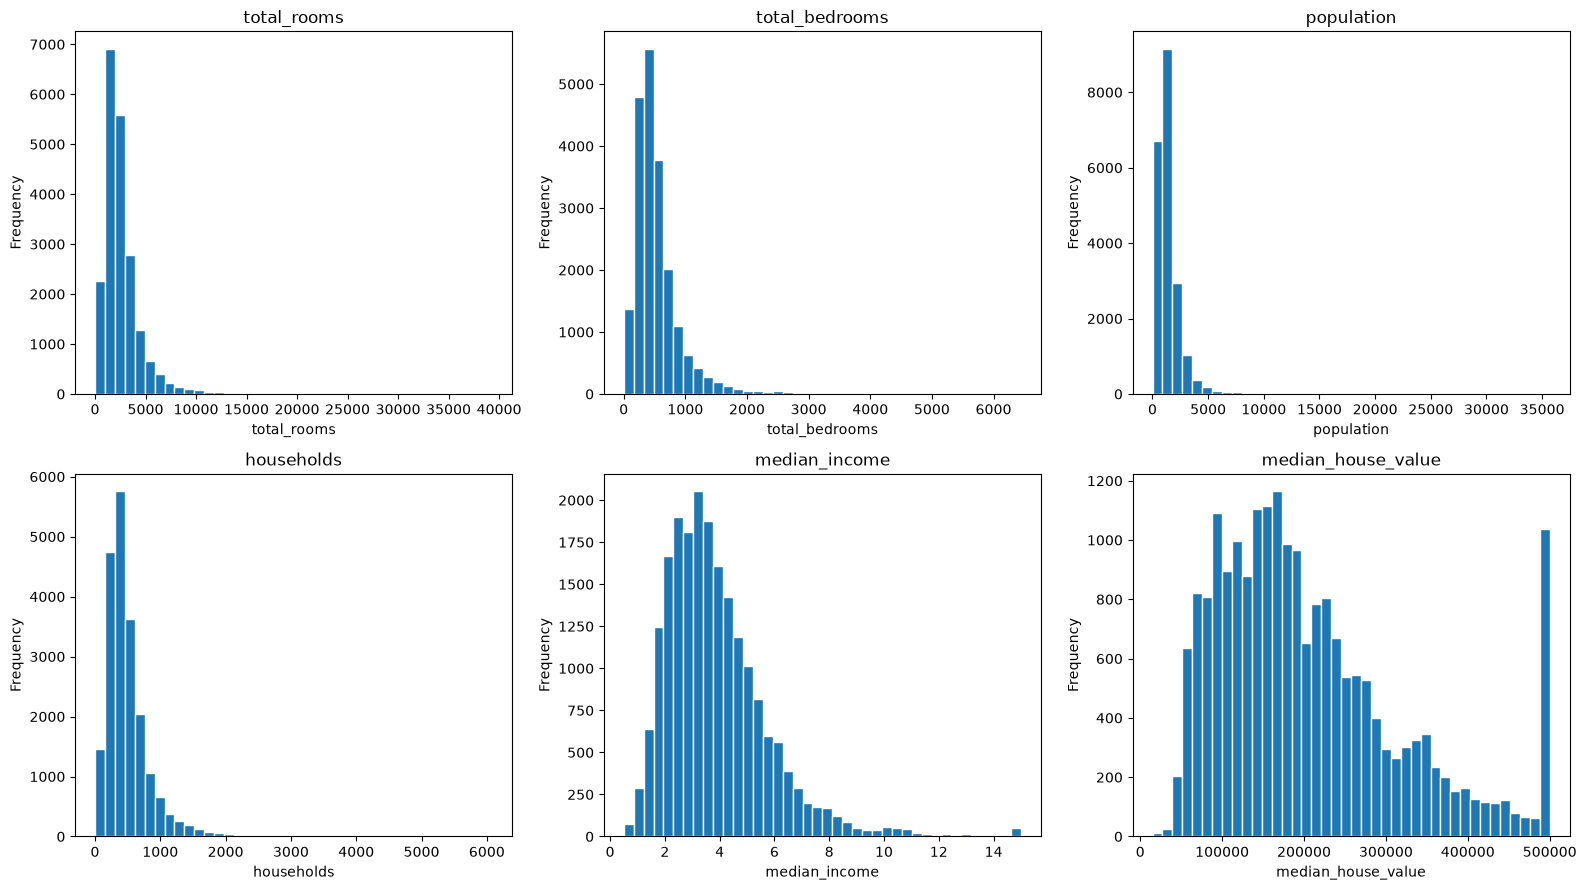

In [11]:
# EDA: inspect distributions, outliers, and relationships
count_columns = ['total_rooms', 'total_bedrooms', 'population', 'households']

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isna().sum())
print('\nSummary statistics:')
display(df[count_columns + ['median_income', 'median_house_value']].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, column in zip(axes.ravel(), count_columns + ['median_income', 'median_house_value']):
    axis.hist(df[column], bins=40, edgecolor='white')
    axis.set_title(column)
    axis.set_xlabel(column)
    axis.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Engineered-feature summary:


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
bedrooms_per_room,20640.0,0.214478,0.069764,0.045937,0.175364,0.203314,0.240255,3.492666
population_per_household,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
log_total_rooms,20640.0,7.629377,0.749991,1.098612,7.278456,7.662938,8.054840,10.579514
log_total_bedrooms,20640.0,6.057063,0.723453,0.693147,5.697093,6.084499,6.468087,8.771215
log_population,20640.0,7.025503,0.736238,1.386294,6.669498,7.062192,7.453562,10.482430
log_households,20640.0,5.984702,0.726740,0.693147,5.638355,6.016157,6.406880,8.713253


,rooms_per_household,bedrooms_per_room,population_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households
0,6.984127,0.146591,2.555556,6.781058,4.867534,5.777652,4.844187
1,6.238137,0.155797,2.109842,8.867850,7.009409,7.784057,7.037906
2,8.288136,0.129516,2.802260,7.291656,5.252273,6.208590,5.181784
3,5.817352,0.184458,2.547945,7.150701,5.463832,6.326149,5.393628
4,6.281853,0.172096,2.181467,7.395108,5.638355,6.338594,5.560682



Correlation with house value:
median_house_value          1.000000
median_income               0.688075
log_total_rooms             0.159422
rooms_per_household         0.151948
log_households              0.073612
log_total_bedrooms          0.053010
log_population             -0.021205
population_per_household   -0.023737
bedrooms_per_room          -0.220049
Name: median_house_value, dtype: float64


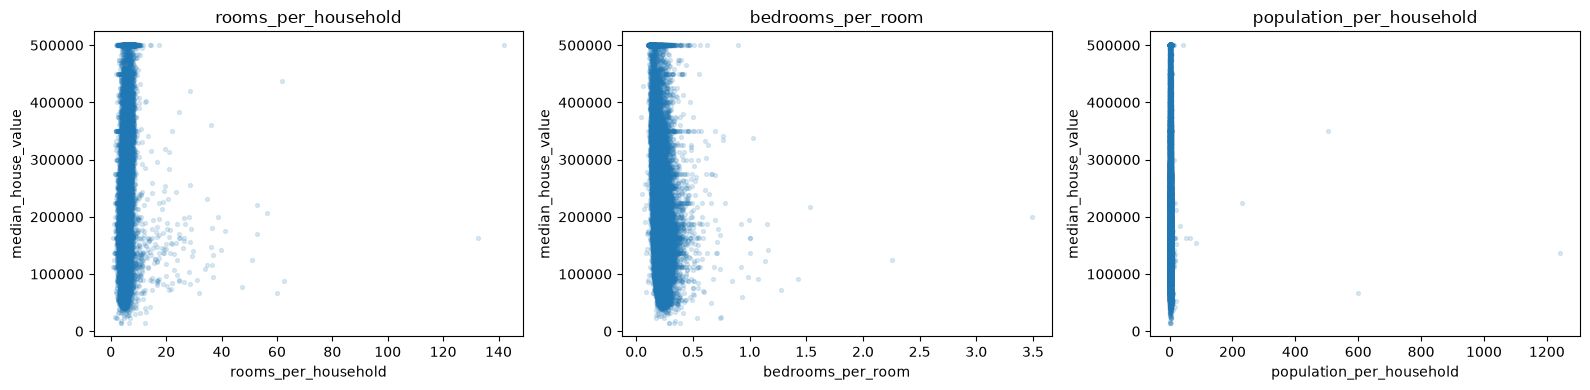

In [13]:
# Feature engineering: make block-group totals easier for a model to interpret
features = df.copy()

features['rooms_per_household'] = features['total_rooms'] / features['households']
features['bedrooms_per_room'] = features['total_bedrooms'] / features['total_rooms']
features['population_per_household'] = features['population'] / features['households']

for column in ['total_rooms', 'total_bedrooms', 'population', 'households']:
    features[f'log_{column}'] = np.log1p(features[column])

engineered_columns = [
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
    'log_total_rooms',
    'log_total_bedrooms',
    'log_population',
    'log_households',
]

print('Engineered-feature summary:')
display(features[engineered_columns].describe().T)
display(features[engineered_columns ].head(5))

print('\nCorrelation with house value:')
print(features[engineered_columns + ['median_income', 'median_house_value']]
      .corr()['median_house_value']
      .sort_values(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, column in zip(axes, ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']):
    axis.scatter(features[column], features['median_house_value'], alpha=0.15, s=8)
    axis.set_title(column)
    axis.set_xlabel(column)
    axis.set_ylabel('median_house_value')
plt.tight_layout()
plt.show()

In [14]:
model_df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)

In [15]:
model_df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,0,0,0,1,0


In [16]:
x = model_df.drop(columns=['median_house_value'])
y = model_df['median_house_value']

In [24]:
# 5. Train/test split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [27]:
# 3. Handle missing values
imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(x_train)
X_test = imputer.transform(x_test)

In [31]:
# 4. Standardize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [33]:
# 5. PCA
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA features:", X_train_pca.shape[1])
print("Explained variance:",
      pca.explained_variance_ratio_.sum())

Original number of features: 15
Number of PCA features: 9
Explained variance: 0.9656886621449671


In [34]:
# 6. Linear Regression
model = LinearRegression()

model.fit(X_train_pca, y_train)


# 7. Prediction
y_pred = model.predict(X_test_pca)


# 8. Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 60683.9844441195
RMSE: 86290.48080986734
R²  : 0.4317768572988795


# Exercise 7 — K-Means Clustering

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       3
1         8.3014     37.86    -122.22       3
2         7.2574     37.85    -122.24       3
3         5.6431     37.85    -122.25       4
4         3.8462     37.85    -122.25       4


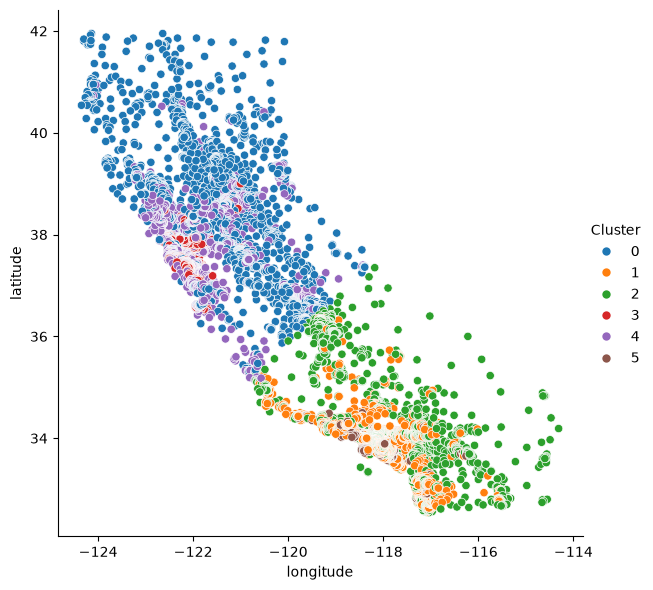

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv("housing.csv")

X = df.loc[:, ["median_income", "latitude", "longitude"]]

print(X.head())

kmeans = KMeans(n_clusters=6)

X["Cluster"] = kmeans.fit_predict(X)

X["Cluster"] = X["Cluster"].astype("category")

print(X.head())

sns.relplot(
    x="longitude",
    y="latitude",
    hue="Cluster",
    data=X,
    height=6,
)

Only three columns are selected:

median_income
latitude
longitude

These become the input variables for K-Means.

median_income tells us about the income level of an area.

latitude and longitude tell us where the houses are geographically located.


kmeans = KMeans(n_clusters=6)

This tells K-Means to divide the data into 6 groups.

The clusters will be numbered:

0
1
2
3
4
5

The code uses K-Means to divide housing areas into six groups based on income and geographical location, and then visualizes those groups on a map.

In [10]:
df['cluster'] = X["Cluster"]

print(df['cluster'].value_counts())


cluster
2    6622
1    4606
0    4519
4    3480
5     741
3     672
Name: count, dtype: int64


# b) Conduct a survey covering demographics, housing preferences, purchasing behavior, communication preferences, and marketing preferences. Sample people from each cluster and compare their answers.

In [12]:

cluster_characteristics = X.groupby("Cluster")[
    ["median_income", "latitude", "longitude"]
].mean()

print(cluster_characteristics)

         median_income   latitude   longitude
Cluster                                      
0             2.509000  38.197269 -121.551916
1             4.938854  33.874900 -118.026379
2             2.639723  33.998408 -117.993133
3             8.262536  37.599613 -122.024524
4             4.628702  37.728175 -121.879397
5             8.992659  33.875735 -118.090121


# c  companies can use the clusters to divide customers into different groups based on their characteristics and preferences. This is called customer segmentation. The company can then create targeted marketing campaigns for each group, recommend suitable products or services, and avoid sending the same advertisement to everyone. This can make marketing more effective and help the company understand its customers better.

Example with the housing dataset

A real-estate company could use the clusters to identify different housing markets:

Cluster 0: Lower-income areas → advertise affordable houses.
Cluster 1: Medium-income areas → advertise standard family homes.
Cluster 2: High-income areas → advertise expensive or luxury houses.

In [13]:
# d.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    scores.append(score)

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.3f}"
    )

K = 2, Silhouette Score = 0.510
K = 3, Silhouette Score = 0.568
K = 4, Silhouette Score = 0.602
K = 5, Silhouette Score = 0.506
K = 6, Silhouette Score = 0.500
K = 7, Silhouette Score = 0.485
K = 8, Silhouette Score = 0.466
K = 9, Silhouette Score = 0.441
K = 10, Silhouette Score = 0.437


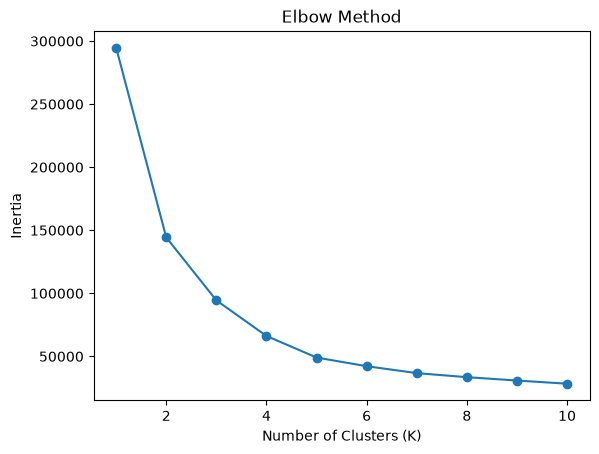

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertias.append(kmeans.inertia_)

plt.plot(
    range(1, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

   median_income  latitude  longitude Cluster Cluster1
0         8.3252     37.88    -122.23       3        1
1         8.3014     37.86    -122.22       3        1
2         7.2574     37.85    -122.24       3        1
3         5.6431     37.85    -122.25       4        1
4         3.8462     37.85    -122.25       4        1


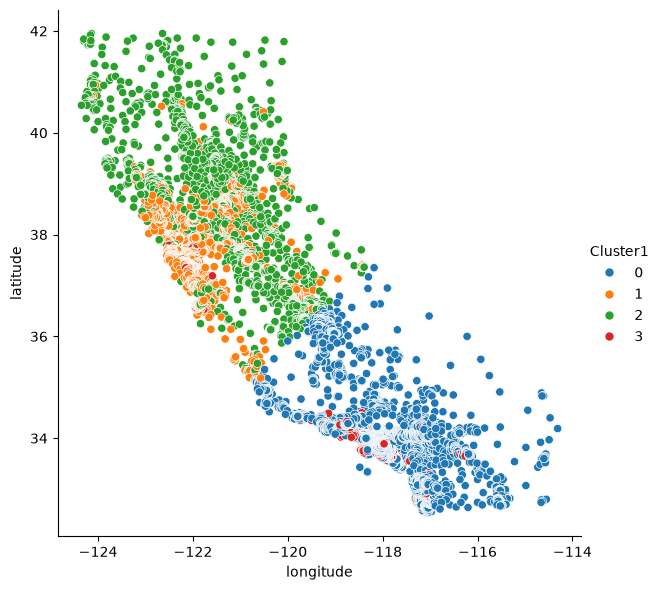

In [18]:
kmeans = KMeans(n_clusters=4,random_state =42)

X["Cluster1"] = kmeans.fit_predict(X)

X["Cluster1"] = X["Cluster1"].astype("category")

print(X.head())

sns.relplot(
    x="longitude",
    y="latitude",
    hue="Cluster1",
    data=X,
    height=6,
)

In [19]:
df['cluster1'] = X["Cluster1"]

print(df['cluster1'].value_counts())

cluster1
0    11228
2     4519
1     4079
3      814
Name: count, dtype: int64


In [20]:
cluster_characteristics = X.groupby("Cluster1")[
    ["median_income", "latitude", "longitude"]
].mean()

print(cluster_characteristics)

          median_income   latitude   longitude
Cluster1                                      
0              3.582883  33.947742 -118.006771
1              5.085550  37.711790 -121.900905
2              2.509000  38.197269 -121.551916
3              9.311929  34.197199 -118.441978
